In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd
import re


In [2]:
# cluedo astronomy version

In [3]:
# what kind of supernova. ec-sne, type Ia, type II.
    # Five of the six cases below are now real numbers, all in the same unit (Msun of each
    # element), with a table + yield-vs-Z plot in that case's cell -- see the citation there for
    # where the numbers come from. For the Cinquegrana+ Type II grid we additionally have the
    # pre-explosion (initial) composition and total ejecta mass for every (Z, M) point (from
    # ExplosiveNucYields/population_yields/), so those two tables show initial, final (ejecta)
    # AND net yield = final - initial; for the two literature (ecSN, Type Ia) cases only the final
    # ejecta mass is published, not the pre-explosion zone composition, so no net yield there --
    # flagged explicitly in those cells rather than guessed.
    #
    # mildly metal-poor type II (Cinquegrana, Heger & Karakas 2025 grid, Z=0.5 Zsun, M=15.1 Msun,
    #   M_ejecta=13.6 Msun): net O yield ~0.275 Msun, net Fe yield ~0.016 Msun -- alpha-rich.
    #   Essentially no weak-s net production anywhere from Ga to Zr (net sum ~2e-6 Msun, i.e.
    #   consistent with zero -- the tiny amount already in the ejecta is inherited, not made).
    # metal-rich type II (same grid, Z=3 Zsun, M=15.1 Msun, M_ejecta=13.5 Msun): net O yield
    #   ~0.100 Msun (smaller than the metal-poor case) and net Fe yield ~0.0035 Msun -- also
    #   smaller. Odd-Z net yield (Na,Al,P,Cl,K,Sc) is ~2x the metal-poor case, and weak-s net
    #   yield is ~15x larger but stays concentrated in Ga-Rb (net ~2.8e-5 Msun) rather than
    #   Sr-Y-Zr (net ~2.3e-6 Msun, 12x less) -- so weak-s isn't "stronger at low Z, cut off at
    #   high Z" as first guessed, it's essentially absent at low Z here and Ga-Rb-only once
    #   metal-rich. NOTE: final (ejecta) Fe mass is actually *larger* at high Z (0.058 vs 0.025
    #   Msun) even though net Fe production is smaller -- most of the "extra" Fe an observer
    #   would see in the ejecta was already in the star to begin with (inherited from a
    #   Z=3 Zsun birth composition), not newly synthesised. Final abundance != net yield.
    # SAGB ec-SN (Wanajo, Nomoto, Janka, Kitaura & Muller 2009, ApJ 695, 208, model ST -- the 1D
    #   neutrino-driven collapse of an 8.8 Msun ONeMg core, i.e. Doherty+ 2015's ecSN mass range):
    #   tiny ejecta (1.4e-2 Msun total) and almost no Fe (56Fe=2.5e-3 Msun), but a clear neutron-
    #   rich, weak r-process-like bump at the light trans-Fe elements (Zn, Ge, Sr, Y, Zr) from the
    #   Ye<0.5 innermost ejecta -- a genuinely distinct fingerprint from either kind of Type II/Ia.
    # metal-poor / metal-rich type Ia (Leung & Nomoto 2018, ApJ 861, 143, rho_c=3e9 c3-flame
    #   near-Chandrasekhar series, Z=0.5 vs Z=3 Zsun): total Fe is nearly flat with Z (0.81 vs
    #   0.77 Msun) -- NOT "weaker/stronger Fe" as first guessed. What actually tracks metallicity
    #   is the make-up of the Fe peak: 54Fe/56Fe roughly doubles (0.14 -> 0.24) and Mn/Fe rises,
    #   because more progenitor neutron excess shifts burning from radioactive 56Ni towards
    #   directly-synthesised neutron-rich stable isotopes -- the same odd-Z/neutron-excess physics
    #   as the Type II odd-Z trend above, not a bigger or smaller Fe yield.
    # heger. PISNe.
    #   -> still literature-only, no numbers pulled yet. Heger & Woosley 2002, ApJ 567, 532
    #      (140-260 Msun, Z=0 grid: strong even/odd-Z alternation, alpha-rich Si-S-Ar-Ca plateau,
    #      hard cutoff at Zn -- no s- or r-process at all, unlike every channel above).

In [4]:
# periodic table: symbol -> atomic (proton) number Z, H through U -- used to turn any yield
# table (elemental columns, as in the Cinquegrana+ grid, or isotope labels like "56Fe"/"90Zr"
# or "Fe56", as in the tables below) into a "yield vs atomic number" table + plot.
ELEMENT_Z = {sym: z for z, sym in enumerate("""
H He Li Be B C N O F Ne Na Mg Al Si P S Cl Ar K Ca Sc Ti V Cr Mn Fe Co Ni Cu Zn
Ga Ge As Se Br Kr Rb Sr Y Zr Nb Mo Tc Ru Rh Pd Ag Cd In Sn Sb Te I Xe Cs Ba La Ce
Pr Nd Pm Sm Eu Gd Tb Dy Ho Er Tm Yb Lu Hf Ta W Re Os Ir Pt Au Hg Tl Pb Bi Po At Rn
Fr Ra Ac Th Pa U
""".split(), start=1)}

def resolve_Z(x):
    """Accept an atomic number or an element symbol ('Fe', 'Ba', ...) and return the atomic number."""
    return ELEMENT_Z[x] if isinstance(x, str) else x

def isotopes_to_elements(series):
    """Sum an isotope-labelled Series ('56Fe', 'Fe56', ...) to one value per element."""
    symbols = [re.sub(r"\d+", "", str(i)) for i in series.index]
    return series.groupby(symbols).sum()

def elemental_table(series, name="yield [Msun]"):
    """Collapse an isotope- or element-labelled Series to one row per element, with its
    atomic number Z. Isotope labels are summed to their element first; already-elemental
    labels ('Fe', 'Zr', as in the Cinquegrana+ grid) pass straight through unchanged."""
    idx = series.index.astype(str)
    if idx.str.match(r"^\d").all():
        series = isotopes_to_elements(series)
    table = series.rename(name).to_frame()
    table["Z"] = table.index.map(ELEMENT_Z)
    return table.dropna(subset=["Z"]).astype({"Z": int}).sort_values("Z")

def plot_yield_vs_Z(table, ycol, title=None, logy=False, symlog=False, ax=None, xlim=None):
    """xlim: optional (low, high) bound on atomic number, each given as an int or an element
    symbol -- e.g. xlim=("Ga", "Zr"), xlim=(31, 40), or a mix like xlim=("Ga", 40)."""
    if xlim is not None:
        lo, hi = resolve_Z(xlim[0]), resolve_Z(xlim[1])
        table = table[(table["Z"] >= lo) & (table["Z"] <= hi)]
    ax = ax or plt.gca()
    ax.plot(table["Z"], table[ycol], marker="o", lw=1)
    if symlog:
        ax.set_yscale("symlog", linthresh=1e-8)
        ax.axhline(0, color="0.7", lw=0.8, zorder=0)
    elif logy:
        ax.set_yscale("log")
    ax.set_xticks(table["Z"])
    ax.set_xticklabels(table.index, rotation=90, fontsize=6)
    ax.set_xlabel("atomic number Z")
    ax.set_ylabel(ycol)
    ax.set_title(title)
    return ax

# --- initial vs final (ejecta) composition, for a genuine net yield = final - initial ---
# Only available for the Cinquegrana+ grid: ExplosiveNucYields/population_yields/ has, for
# every (Z, M) grid point, the total ejecta mass (masses.csv) *and* the initial (pre-explosion,
# Z-scaled-solar) isotopic mass fractions used as the starting composition for that model
# (initia_abunds/z*.csv) -- exactly what the population_yields notebooks there use to compute
# net yields themselves. The Wanajo/Leung-Nomoto literature tables below only publish the final
# ejecta mass, not the pre-explosion zone composition, so a true net yield can't be recovered
# for those two without going back to their stellar/WD models directly.
POP_dir = Path("../../../ExplosiveNucYields/population_yields")
_masses = pd.read_csv(POP_dir / "masses.csv")
Z_LABEL = {0: "z0p00714", 1: "z0p00714", 2: "z0p01", 3: "z0p016", 4: "z0p025", 5: "z0p0357",
           6: "z0p05", 7: "z0p0714", 8: "z0p12", 10: "z0p25", 11: "z0p357",
           12: "z0p5", 13: "z0p75", 14: "z01", 15: "z02", 16: "z03", 17: "z04", 18: "z05"}
# (Z_init=9, Z=0.16 Zsun, has no matching initia_abunds file -- left out rather than guessed)

def match_ejecta_mass(z_init, z_grid, target_mass):
    """Nearest-neighbour match into masses.csv, which stores the exact (Z, M) grid used --
    total ejecta mass (M_ZAMS - M_remnant) for that specific model, in Msun."""
    zs = _masses["z"].unique()
    zbest = zs[np.argmin(np.abs(zs - z_grid[z_init]))]
    sub = _masses[_masses["z"] == zbest]
    mbest = sub["m"].values[np.argmin(np.abs(sub["m"].values - target_mass))]
    return sub[sub["m"] == mbest].iloc[0]["yd_mass"]

def load_initial_massfrac(z_init):
    df = pd.read_csv(POP_dir / "initia_abunds" / f"{Z_LABEL[z_init]}.csv")
    return isotopes_to_elements(df.iloc[0])

CINQUEGRANA_dir = Path("../../../ExplosiveNucYields/Yields_Oct2025/plot_local")
Z_GRID = [0.007, 0.00714, 0.01, 0.016, 0.025, 0.036, 0.05, 0.0714, 0.12, 0.16, 0.25, 0.36, 0.50, 0.75, 1, 2, 3, 4, 5]

def cinquegrana_log_abundances(z_init, m_init):
    """[X] = log10(X_ejecta / X_solar) at one (Z_init, M_init) grid point, for every
    element the grid provides (yields_a/b/c.csv split C-Cu / Zn-Xe / Cs-Au)."""
    parts = []
    for letter in "abc":
        df = pd.read_csv(CINQUEGRANA_dir / f"yields_{letter}.csv")
        match = df[(df.Z_init == z_init) & (df.M_init == m_init)].iloc[0]
        parts.append(match.drop(["Z_init", "M_init"]))
    return pd.concat(parts)

def cinquegrana_yields(z_init, m_init=20, target_mass=15.125):
    """Initial, final (ejecta) and net-yield elemental masses [Msun] at one grid point.
    final = 10^[X] * X_solar * M_ejecta; initial = X_init(Z) * M_ejecta; net = final - initial."""
    log_X = cinquegrana_log_abundances(z_init, m_init)
    M_ej = match_ejecta_mass(z_init, Z_GRID, target_mass)
    X_solar = load_initial_massfrac(14)  # Z_init=14 -> Z=1 Zsun -> solar reference
    X_init = load_initial_massfrac(z_init)
    elems = log_X.index
    final = (10 ** log_X) * X_solar.reindex(elems).fillna(0) * M_ej
    initial = X_init.reindex(elems).fillna(0) * M_ej
    table = pd.DataFrame({"initial [Msun]": initial, "final [Msun]": final,
                           "net yield [Msun]": final - initial})
    table["Z"] = table.index.map(ELEMENT_Z)
    return table.dropna(subset=["Z"]).astype({"Z": int}).sort_values("Z"), M_ej

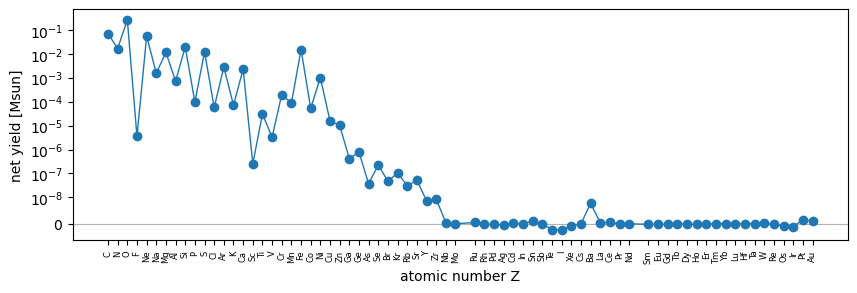

In [5]:
table_mp_II, M_ej_mp_II = cinquegrana_yields(z_init=12)
# display(table_mp_II)

# fig, ax = plt.subplots(figsize=(10, 3))
# plot_yield_vs_Z(table_mp_II, "net yield [Msun]", "Mildly metal-poor Type II (Z=0.5 Zsun, M=15.1 Msun): net yield", symlog=True)
# plt.show()

table_mr_II, M_ej_mr_II = cinquegrana_yields(z_init=16)
# display(table_mr_II)

# fig, ax = plt.subplots(figsize=(10, 3))
# plot_yield_vs_Z(table_mr_II, "net yield [Msun]", "Metal-rich Type II (Z=3 Zsun, M=15.1 Msun): net yield", symlog=True)
# plt.show()

fig, ax = plt.subplots(figsize=(10, 3))
# plot_yield_vs_Z(table_mp_II, "net yield [Msun]", symlog=True)
# plot_yield_vs_Z(table_mr_II, "net yield [Msun]", symlog=True)

plot_yield_vs_Z(table_mp_II, "net yield [Msun]", symlog=True)


plt.show()

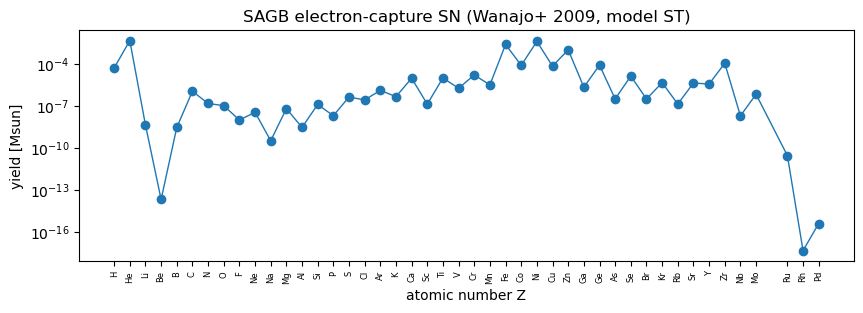

In [6]:
LITERATURE_dir = Path("../../.lab_ideas/labs/yields/literature")

# SAGB ec-SN: Wanajo, Nomoto, Janka, Kitaura & Muller 2009, ApJ 695, 208, model ST -- a 1D
# neutrino-driven explosion of an 8.8 Msun ONeMg core (the collapse-to-neutron-star channel
# Doherty+ 2015's mass range points to, not the alternative thermonuclear disruption some 3D
# deflagration models find for the same core). Table 2 gives isotope yields already decayed to
# their final stable daughters -- this is the *gross* ejecta mass, not a net yield: the paper
# doesn't publish the pre-explosion composition of the collapsing zone, so final-minus-initial
# isn't recoverable here the way it is for the Cinquegrana+ grid above.
wanajo_df = pd.read_csv(LITERATURE_dir / "wanajo2009_ecsn.dat", sep=r"\s+", comment="#")
wanajo_df = wanajo_df.set_index("isotope")

abund_ecsn = wanajo_df["ST"]
# print("SAGB electron-capture SN (Wanajo+ 2009, model ST): ejecta mass [Msun] (gross, not net)")

table_ecsn = elemental_table(abund_ecsn)
# display(table_ecsn)

fig, ax = plt.subplots(figsize=(10, 3))
plot_yield_vs_Z(table_ecsn, "yield [Msun]", "SAGB electron-capture SN (Wanajo+ 2009, model ST)", logy=True)
plt.show()

# print(f"total ejecta mass = {abund_ecsn.sum():.3e} Msun  (tiny -- ecSNe barely enrich anything)")
# print(f"56Fe = {abund_ecsn['56Fe']:.3e}, 64Zn = {abund_ecsn['64Zn']:.3e}, 90Zr = {abund_ecsn['90Zr']:.3e} Msun")
# print("-> almost no Fe, but a weak r-process-like bump at the neutron-rich light trans-Fe")
# print("   elements (Zn, Ge, Sr, Y, Zr) from the Ye<0.5 innermost ejecta -- the ecSN fingerprint.")

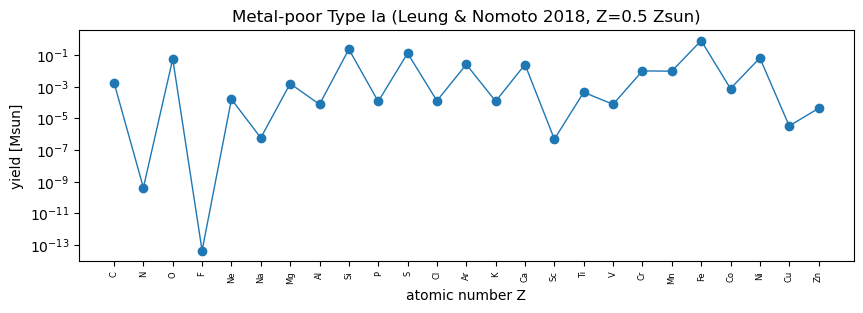

In [7]:
# metal-poor / metal-rich type Ia: Leung & Nomoto 2018, ApJ 861, 143, the rho_c=3e9 g/cm^3,
# c3-flame, C/O=1 near-Chandrasekhar deflagration series (models 300-Z-c3-1), which they ran at
# seven Z. We use Z=0.5 and Z=3 Zsun below -- the same two metallicities as the Type II cells
# above, so all four SN clues are directly comparable at like-for-like [Fe/H]. Also gross ejecta,
# not net yield: the WD's initial composition (mostly C/O, plus a Z-scaled trace of everything
# else) isn't broken out per element in these tables, only the post-explosion ejecta is.
leung_df = pd.read_csv(LITERATURE_dir / "leung_nomoto2018_typeIa.dat", sep=r"\s+", comment="#")
leung_df = leung_df[leung_df["radioactive"] == 0].set_index("isotope")  # final, fully-decayed yields

abund_ia_mp = leung_df["Z0p5"]
# print("Metal-poor Type Ia (Leung & Nomoto 2018, Z=0.5 Zsun): ejecta mass [Msun] (gross, not net)")

table_ia_mp = elemental_table(abund_ia_mp)
# display(table_ia_mp)

fig, ax = plt.subplots(figsize=(10, 3))
plot_yield_vs_Z(table_ia_mp, "yield [Msun]", "Metal-poor Type Ia (Leung & Nomoto 2018, Z=0.5 Zsun)", logy=True)
plt.show()

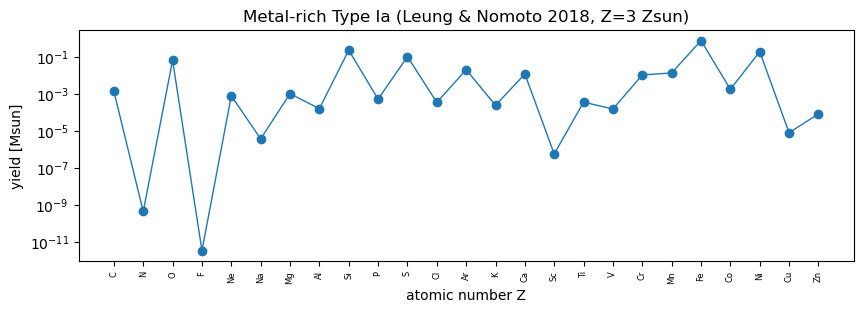

In [8]:
abund_ia_mr = leung_df["Z3"]
# print("Metal-rich Type Ia (Leung & Nomoto 2018, Z=3 Zsun): ejecta mass [Msun] (gross, not net)")

table_ia_mr = elemental_table(abund_ia_mr)
# display(table_ia_mr)

fig, ax = plt.subplots(figsize=(10, 3))
plot_yield_vs_Z(table_ia_mr, "yield [Msun]", "Metal-rich Type Ia (Leung & Nomoto 2018, Z=3 Zsun)", logy=True)
plt.show()

fe_isotopes = ["54Fe", "56Fe", "57Fe", "58Fe"]
# print(f"\ntotal Fe: Z=0.5 -> {abund_ia_mp[fe_isotopes].sum():.3e} Msun,"
#       f"  Z=3 -> {abund_ia_mr[fe_isotopes].sum():.3e} Msun")
# print(f"54Fe/56Fe: Z=0.5 -> {abund_ia_mp['54Fe']/abund_ia_mp['56Fe']:.3f},"
#       f"  Z=3 -> {abund_ia_mr['54Fe']/abund_ia_mr['56Fe']:.3f}")
# print("-> total Fe is nearly flat with Z here (Nomoto's W7-family result); what actually moves")
# print("   is the *make-up* of the Fe peak -- 54Fe/56Fe and Mn/Fe rise sharply with Z, because more")
# print("   neutron excess pushes burning towards directly-synthesised neutron-rich stable isotopes")
# print("   instead of radioactive 56Ni. So the metal-rich \"stronger Fe\" clue is really this")
# print("   neutron-rich/odd-Z shift, not a bigger total Fe yield -- same underlying physics as the")
# print("   odd-Z trend in the Type II cells above.")

In [9]:
# IMS agb. primary or secondary N?
    # Two real M=6 Msun cases below, light elements up to Fe only (both networks used here stop
    # shortly after Fe/Ni anyway) -- see each cell for the exact model and what "yield" means.
    # metal-poor: Karakas & Lugaro 2016, Z=0.007 (their lowest Z). KL16 explicitly run *without*
    #   a 13C-pocket/PMZ at M=6 -- all their M>5 Msun models are pocket-free at every metallicity,
    #   s-process there comes only from the 22Ne(a,n)25Mg source instead. So this is NOT
    #   PMZ-matched to the metal-rich case below (there's no KL16 6 Msun model that is).
    # metal-rich: Cinquegrana & Karakas 2022, Z=0.04, M=6 -- one of the three Z (0.04-0.06) they
    #   also post-processed with a 328-species network for s-process; here we only need the
    #   light-element part, already in their standard 77-species production grid.
    #
    # Metal-rich net yield (can be negative -- newly made minus destroyed): H strongly
    #   net-negative (burned), He strongly net-positive, and N strongly net-positive *together
    #   with* net-negative C -- the HBB CN-cycle fingerprint (C is actively being converted to N
    #   at the base of the envelope, not just passively diluted). Ne-Na and Mg-Al chain products
    #   (Ne, Na, Mg, Al) all mildly net-positive. Distinguishing primary vs secondary N here would
    #   need the C isotope ratio or a Z-sequence, not just this one point -- not attempted.
    # Metal-poor: KL16's file gives gross ejecta mass, not net yield (no initial-composition
    #   breakdown available the way the Cinquegrana+ SNe grid had) -- so its numbers compare to
    #   the metal-rich case in relative shape across elements only, not directly in scale.

,Z,yield [Msun]
symbol,,
H,1,3.260000e+00
He,2,1.740000e+00
C,6,4.070000e-03
N,7,4.010000e-02
O,8,7.600000e-03
F,9,2.670000e-07
Ne,10,4.210000e-03
Na,11,1.070000e-04
Mg,12,2.050000e-03


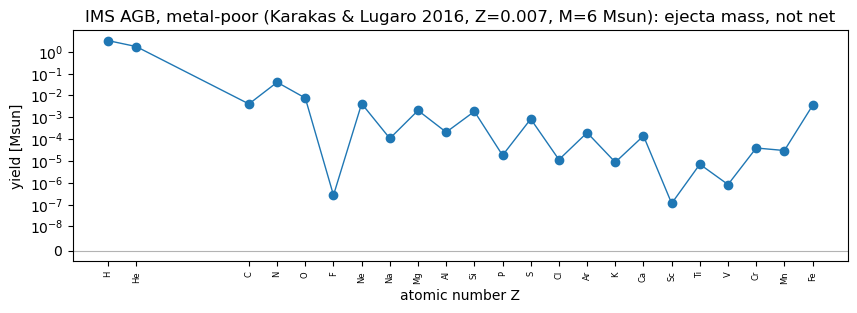

In [10]:
KLC25_dir = Path("../../.lab_ideas/labs/yields/KLC25")
Z_TO_ELEMENT = {z: sym for sym, z in ELEMENT_Z.items()}

# IMS AGB, metal-poor: Karakas & Lugaro 2016, ApJ 825, 26, Z=0.007, M=6 Msun. Columns are
# [mass, Zini, mrem, el, Z, yield]; "el" ambiguously reuses "p" for both H (Z=1) and P (Z=15),
# so we index elements by the Z column rather than trusting the text label.
def load_kl16_elements(z_str, mass, zmax=26):
    df = pd.read_csv(KLC25_dir / f"KL16_z{z_str}.dat", sep=r"\s+", header=None,
                      names=["mass", "Zini", "mrem", "el", "Z", "yield [Msun]"])
    sub = df[(df["mass"] == mass) & (df["Z"] <= zmax)].copy()
    sub["symbol"] = sub["Z"].map(Z_TO_ELEMENT)
    return sub.set_index("symbol")[["Z", "yield [Msun]"]].sort_values("Z")

table_agb_mp = load_kl16_elements("007", 6.00)
display(table_agb_mp)

fig, ax = plt.subplots(figsize=(10, 3))
plot_yield_vs_Z(table_agb_mp, "yield [Msun]",
                 "IMS AGB, metal-poor (Karakas & Lugaro 2016, Z=0.007, M=6 Msun): ejecta mass, not net",
                 symlog=True)
plt.show()

,yield [Msun],Z
symbol,,
H,-2.860000e-01,1
He,2.750714e-01,2
Li,-1.320000e-07,3
Be,7.370000e-07,4
B,6.270000e-22,5
C,-1.089992e-02,6
N,3.027420e-02,7
O,-9.973000e-03,8
F,1.020000e-06,9


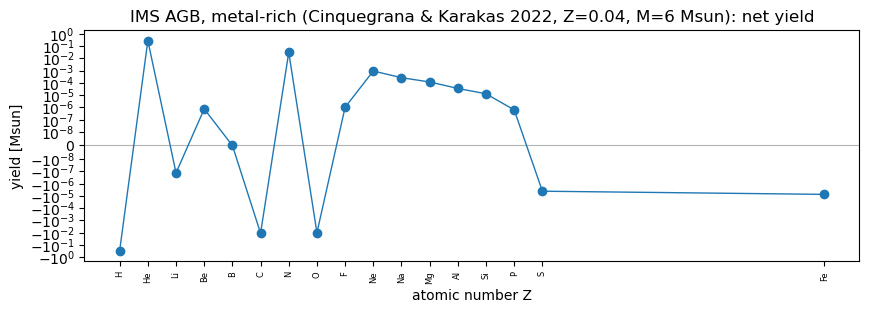

In [11]:
# IMS AGB, metal-rich: Cinquegrana & Karakas 2022, MNRAS 510, 1557, Z=0.04, M=6 Msun -- one of
# the three Z (0.04-0.06) also post-processed with a 328-species network for s-process in that
# paper; we only need the light-element part here, already in their standard 77-species grid.
# Columns are [mass, c2, c3, el, A, yield] with "el" isotope-labelled (e.g. "fe56") and the
# numeric column A the *mass* number, not atomic number -- unlike the KL16 file above. "yield" is
# a genuine net yield (can be negative), not gross ejecta mass. NOTE: this file's Zini/mrem
# columns (c2, c3) are swapped relative to every other KLC25 file -- Z=0.04 taken from the
# filename directly rather than trusting either column.
def ck22_symbol(el):
    if el in ("p", "d"):
        return "H"          # protons/deuterons = hydrogen; "n" (neutron) and "g" (gammas) dropped
    return re.match(r"[a-zA-Z]+", el).group(0).capitalize()

def load_ck22_elements(z_str, mass, zmax=26):
    df = pd.read_csv(KLC25_dir / f"CK22_z{z_str}.dat", sep=r"\s+", header=None,
                      names=["mass", "c2", "c3", "el", "A", "yield [Msun]"])
    sub = df[(df["mass"] == mass) & (~df["el"].isin(["g", "n"]))].copy()
    sub["symbol"] = sub["el"].map(ck22_symbol)
    out = sub.groupby("symbol")["yield [Msun]"].sum().to_frame()
    out["Z"] = out.index.map(ELEMENT_Z)
    return out.dropna(subset=["Z"]).astype({"Z": int}).query("Z <= @zmax").sort_values("Z")

table_agb_mr = load_ck22_elements("04", 6.00)
display(table_agb_mr)

fig, ax = plt.subplots(figsize=(10, 3))
plot_yield_vs_Z(table_agb_mr, "yield [Msun]",
                 "IMS AGB, metal-rich (Cinquegrana & Karakas 2022, Z=0.04, M=6 Msun): net yield",
                 symlog=True)
plt.show()

In [12]:
# extrinsic or intrinsic. agb signature with Tc. how could we tell if the star is intrinsic or extrinsic?

In [13]:
# s vs r process.
    # sprocess. high eu but higher ba.
    # weak r process signature.
    #
    # Two real, observed stars below, each already matched against a theoretical pattern in its
    # discovery paper (not just an s/r label from the literature) -- see each cell for the fit.
    # CEMP-s: CS 29497-030 (Ivans et al. 2005). Matched against a Goriely & Mowlavi 2000
    #   Z=0.001 AGB model and, in the same paper, a 1.3 Msun AGB s-process model diluted by a
    #   factor of 2 into an unprocessed envelope (the mass-transfer binary picture). [Fe/H]=-2.70.
    # CEMP-r (r-II): CS 22892-052 (Sneden et al. 2003). Matched against the scaled solar-system
    #   r-process-only residual pattern (Arlandini et al. 1999), shifted to match the observed Eu
    #   -- the classic demonstration that Ba-through-actinide production tracks the r-process
    #   curve almost exactly, not the s-process one. [Fe/H]=-3.10.
    #
    # The Ba/Eu contrast the comment above is describing, with real numbers:
    #   CS 29497-030 (CEMP-s): [Ba/Fe]=+2.17, [Eu/Fe]=+1.44 -> [Ba/Eu]=+0.73 (Ba >> Eu: s-process).
    #   CS 22892-052 (CEMP-r): [Ba/Fe]=+0.99, [Eu/Fe]=+1.64 -> [Ba/Eu]=-0.65 (Eu >> Ba: r-process).
    # Same two elements, opposite sign of the ratio -- that flip is the actual s-vs-r diagnostic,
    # not either element enhancement alone (both stars have [Eu/Fe]>0 and [Ba/Fe]>0).

,Z,[X/Fe]
symbol,,
C,6,2.690
O,8,1.670
Na,11,0.520
Mg,12,0.590
Al,13,-0.670
Si,14,0.275
S,16,0.400
Ca,20,0.330
Sc,21,0.300


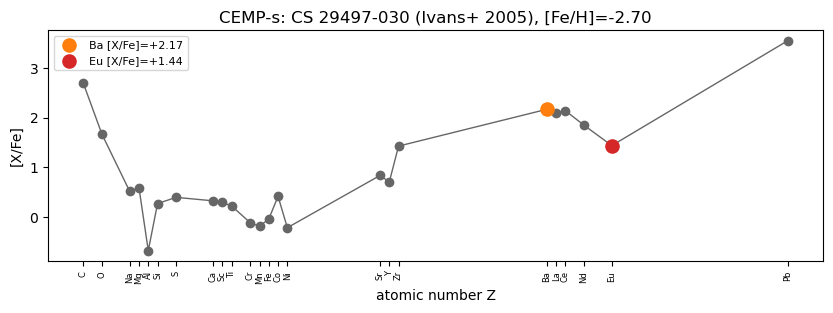

In [14]:
def load_star_abundances(filename):
    df = pd.read_csv(LITERATURE_dir / filename, sep=r"\s+", comment="#")
    return df.set_index("symbol").sort_values("Z")

def plot_star_pattern(table, title, ax=None):
    ax = ax or plt.gca()
    ax.plot(table["Z"], table["[X/Fe]"], marker="o", lw=1, color="0.4", zorder=1)
    for sym in ("Ba", "Eu"):
        if sym in table.index:
            z, xfe = table.loc[sym, ["Z", "[X/Fe]"]]
            ax.scatter([z], [xfe], s=90, zorder=2, label=f"{sym} [X/Fe]={xfe:+.2f}",
                       color="tab:orange" if sym == "Ba" else "tab:red")
    ax.set_xticks(table["Z"])
    ax.set_xticklabels(table.index, rotation=90, fontsize=6)
    ax.set_xlabel("atomic number Z")
    ax.set_ylabel("[X/Fe]")
    ax.set_title(title)
    ax.legend(fontsize=8)
    return ax

# CEMP-s: CS 29497-030 (Ivans et al. 2005) -- matched against a Goriely & Mowlavi (2000)
# Z=0.001 AGB model and a 1.3 Msun AGB s-process model diluted by a factor of 2.
table_cemps = load_star_abundances("ivans2005_cs29497-030.dat")
display(table_cemps)

fig, ax = plt.subplots(figsize=(10, 3))
plot_star_pattern(table_cemps, "CEMP-s: CS 29497-030 (Ivans+ 2005), [Fe/H]=-2.70")
plt.show()

,Z,[X/Fe]
symbol,,
Sr,38,0.605
Y,39,0.440
Zr,40,0.775
Nb,41,0.880
Mo,42,0.780
Ru,44,1.340
Rh,45,1.430
Pd,46,1.120
Ag,47,0.980


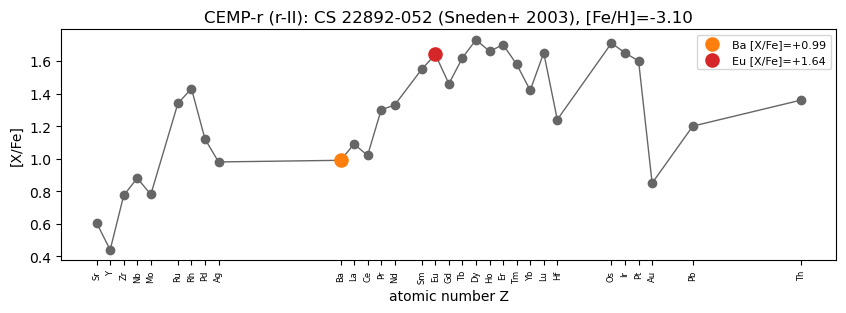

[Ba/Eu]: CS 29497-030 (CEMP-s) = +0.73   CS 22892-052 (CEMP-r) = -0.65


In [15]:
# CEMP-r (r-II): CS 22892-052 (Sneden et al. 2003) -- matched against the scaled solar-system
# r-process-only residual pattern, shifted to match the observed Eu. [X/Fe] here is recomputed
# as [X/H]-[Fe/H] rather than taken from the paper's own column: their published La II [X/Fe]
# (+3.09) is a typo (their own [X/H]=-2.01 implies +1.09, matching neighbouring Ce/Pr) -- fixed
# in the saved data file, not silently carried through.
table_cempr = load_star_abundances("sneden2003_cs22892-052.dat")
display(table_cempr)

fig, ax = plt.subplots(figsize=(10, 3))
plot_star_pattern(table_cempr, "CEMP-r (r-II): CS 22892-052 (Sneden+ 2003), [Fe/H]=-3.10")
plt.show()

print(f"[Ba/Eu]: CS 29497-030 (CEMP-s) = {table_cemps.loc['Ba','[X/Fe]'] - table_cemps.loc['Eu','[X/Fe]']:+.2f}"
      f"   CS 22892-052 (CEMP-r) = {table_cempr.loc['Ba','[X/Fe]'] - table_cempr.loc['Eu','[X/Fe]']:+.2f}")

In [16]:
# Extension. 
# what could be causing the difference in C. (binary vs single star). 